# Personalized Learning Recommendation System

## Overview

This project implements a content-based recommendation system that suggests relevant online courses based on course similarity and user skills.

The recommendation engine uses:

- TF-IDF Vectorization
- Cosine Similarity
- Content-Based Filtering

Dataset: Coursera Online Courses Dataset (750 courses)

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Dataset Loading

The Coursera dataset is loaded and the first 750 courses are selected for analysis and recommendation generation.

In [2]:
df = pd.read_csv("Coursera.csv")

df.head()

,partner,course,skills,rating,reviewcount,level,certificatetype,duration,crediteligibility
0,Google,Google Cybersecurity,"{"" Network Security"","" Python Programming"","" L...",4.8,16.4k,Beginner,Professional Certificate,3 - 6 Months,False
1,Google,Google Data Analytics,"{"" Data Analysis"","" R Programming"","" SQL"","" Bu...",4.8,133.4k,Beginner,Professional Certificate,3 - 6 Months,True
2,Google,Google Project Management:,"{"" Project Management"","" Strategy and Operatio...",4.8,97.3k,Beginner,Professional Certificate,3 - 6 Months,True
3,Google,Google Digital Marketing & E-commerce,"{"" Digital Marketing"","" Marketing"","" Marketing...",4.8,21.4k,Beginner,Professional Certificate,3 - 6 Months,False
4,Google,Google IT Support,"{"" Computer Networking"","" Network Architecture...",4.8,181.4k,Beginner,Professional Certificate,3 - 6 Months,True


In [3]:
df = df.head(750)

print(df.shape)

(750, 9)


## Data Preprocessing

The dataset is cleaned by:

- Handling missing values
- Removing records with missing course names
- Preparing text features for recommendation

In [4]:
print(df.isnull().sum())

partner               0
course                0
skills                0
rating               16
reviewcount          16
level                13
certificatetype      15
duration             15
crediteligibility     0
dtype: int64


In [5]:
df['skills'] = df['skills'].fillna('')
df['level'] = df['level'].fillna('Unknown')

df.dropna(subset=['course'], inplace=True)

## Feature Engineering

A new feature column is created by combining skills and difficulty level.

This combined feature will be used for content-based recommendations.

In [6]:
df['features'] = (
    df['skills'].astype(str)
    + " "
    + df['level'].astype(str)
)

In [7]:
df[['course','features']].head()

,course,features
0,Google Cybersecurity,"{"" Network Security"","" Python Programming"","" L..."
1,Google Data Analytics,"{"" Data Analysis"","" R Programming"","" SQL"","" Bu..."
2,Google Project Management:,"{"" Project Management"","" Strategy and Operatio..."
3,Google Digital Marketing & E-commerce,"{"" Digital Marketing"","" Marketing"","" Marketing..."
4,Google IT Support,"{"" Computer Networking"","" Network Architecture..."


## TF-IDF Vectorization

Textual features are converted into numerical vectors using TF-IDF (Term Frequency–Inverse Document Frequency).

This helps identify important terms while reducing the impact of common words.

In [8]:
vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = vectorizer.fit_transform(df['features'])

similarity_matrix = cosine_similarity(tfidf_matrix)

In [9]:
def recommend_courses(course_name):

    idx = df[df['course'] == course_name].index[0]

    scores = list(enumerate(similarity_matrix[idx]))

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = scores[1:6]

    print("\nRecommended Courses:\n")

    for i in recommendations:
        print(df.iloc[i[0]]['course'])

In [10]:
df['course'].head(20)

0                              Google Cybersecurity
1                             Google Data Analytics
2                        Google Project Management:
3             Google Digital Marketing & E-commerce
4                                 Google IT Support
5                                  IBM Data Science
6                                  Google UX Design
7                                  IBM Data Analyst
8                                  Machine Learning
9                      Introduction to Data Science
10                       Generative AI for Everyone
11              IBM DevOps and Software Engineering
12                IBM Full Stack Software Developer
13                    Key Technologies for Business
14    Data Science Fundamentals with Python and SQL
15                    IBM & Darden Digital Strategy
16                             IBM Data Engineering
17              IBM Data Analytics with Excel and R
18      Data Analysis and Visualization Foundations
19          

In [11]:
recommend_courses("Python for Everybody")


Recommended Courses:

Meta Database Engineer
SQL for Data Science
Databases and SQL for Data Science with Python
Learn SQL Basics for Data Science
Data Engineering Foundations


In [12]:
df.head

<bound method NDFrame.head of                                         partner  \
0                                        Google   
1                                        Google   
2                                        Google   
3                                        Google   
4                                        Google   
..                                          ...   
745                        University of London   
746                             Duke University   
747                   Michigan State University   
748  Rutgers the State University of New Jersey   
749                        University of London   

                                              course  \
0                               Google Cybersecurity   
1                              Google Data Analytics   
2                         Google Project Management:   
3              Google Digital Marketing & E-commerce   
4                                  Google IT Support   
..                   

## Similarity Computation

Cosine Similarity is used to measure the similarity between courses based on their TF-IDF vectors.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = vectorizer.fit_transform(df['features'])

print(tfidf_matrix.shape)

(750, 353)


In [14]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(tfidf_matrix)

print(similarity_matrix.shape)

(750, 750)


## Course-Based Recommendation Function

This function recommends similar courses based on a selected course.

In [15]:
def recommend_courses(course_name):

    if course_name not in df['course'].values:
        print("Course not found!")
        return

    idx = df[df['course'] == course_name].index[0]

    scores = list(enumerate(similarity_matrix[idx]))

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = scores[1:6]

    print("\nTop 5 Recommended Courses:\n")

    for i in recommendations:
        print(df.iloc[i[0]]['course'])

In [16]:
df['course'].head(20)

0                              Google Cybersecurity
1                             Google Data Analytics
2                        Google Project Management:
3             Google Digital Marketing & E-commerce
4                                 Google IT Support
5                                  IBM Data Science
6                                  Google UX Design
7                                  IBM Data Analyst
8                                  Machine Learning
9                      Introduction to Data Science
10                       Generative AI for Everyone
11              IBM DevOps and Software Engineering
12                IBM Full Stack Software Developer
13                    Key Technologies for Business
14    Data Science Fundamentals with Python and SQL
15                    IBM & Darden Digital Strategy
16                             IBM Data Engineering
17              IBM Data Analytics with Excel and R
18      Data Analysis and Visualization Foundations
19          

## Course Recommendation Example

In [17]:
recommend_courses("Google Data Analytics")


Top 5 Recommended Courses:

Google データアナリティクス
Data Analysis and Presentation Skills: the PwC Approach
Excel to MySQL: Analytic Techniques for Business
Análisis de Datos de Google
Google Data Analytics (PT)


## Skill-Based Recommendation Function

This function recommends courses based on user-entered skills and interests.

In [18]:
def recommend_by_skill(skill):

    skill_vector = vectorizer.transform([skill])

    similarity_scores = cosine_similarity(
        skill_vector,
        tfidf_matrix
    ).flatten()

    top_indices = similarity_scores.argsort()[-5:][::-1]

    print(f"\nTop Courses for '{skill}':\n")

    for idx in top_indices:

        print(
            f"{df.iloc[idx]['course']} "
            f"(Rating: {df.iloc[idx]['rating']})"
        )

## Skill-Based Recommendation Examples

In [19]:
recommend_by_skill("Python")


Top Courses for 'Python':

Fundamentos de la ciberseguridad (Rating: 4.9)
Using Python to Interact with the Operating System (Rating: 4.7)
Python Functions, Files, and Dictionaries (Rating: 4.9)
Data Collection and Processing with Python (Rating: 4.7)
Python for Data Science, AI & Development (Rating: 4.6)


In [20]:
recommend_by_skill("Machine Learning")


Top Courses for 'Machine Learning':

Generative AI Fundamentals (Rating: 4.6)
Fundamentals of Machine Learning for Healthcare (Rating: 4.8)
Unsupervised Learning, Recommenders, Reinforcement Learning (Rating: 4.9)
Supervised Machine Learning: Regression and Classification (Rating: 4.9)
AI For Everyone （すべての人のためのAIリテラシー講座） (Rating: 4.8)


In [21]:
recommend_by_skill("Data Analysis")


Top Courses for 'Data Analysis':

ChatGPT Advanced Data Analysis (Rating: 4.9)
Aspectos básicos: Datos, datos, en todas partes (Rating: 4.8)
DataOps Methodology (Rating: 4.7)
Introduction to Clinical Data (Rating: 4.6)
Excel to MySQL: Analytic Techniques for Business (Rating: 4.6)


## Data Visualization

The following visualization shows the highest-rated courses in the dataset.

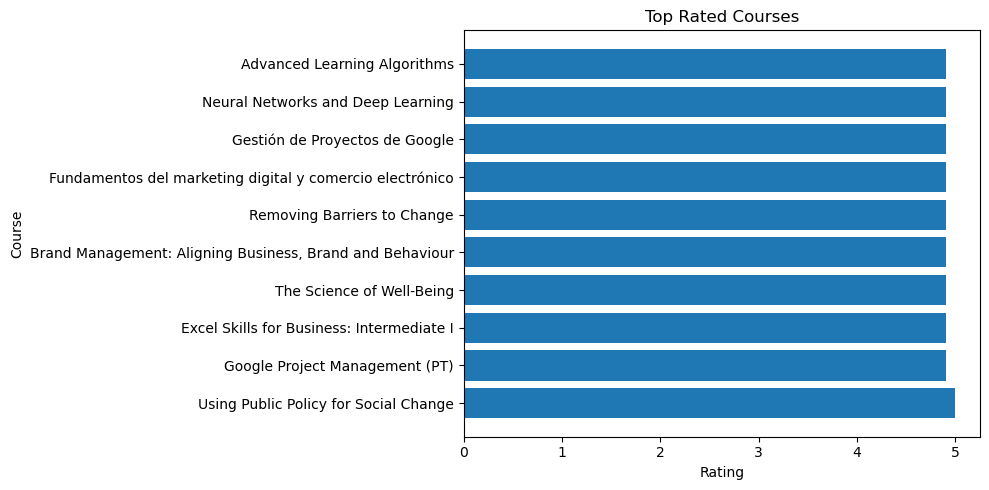

In [22]:
import matplotlib.pyplot as plt

top_courses = df.sort_values(
    by='rating',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_courses['course'],
    top_courses['rating']
)

plt.xlabel("Rating")
plt.ylabel("Course")
plt.title("Top Rated Courses")

plt.tight_layout()

plt.show()

## Course Level Distribution

This chart displays the distribution of courses across different difficulty levels.

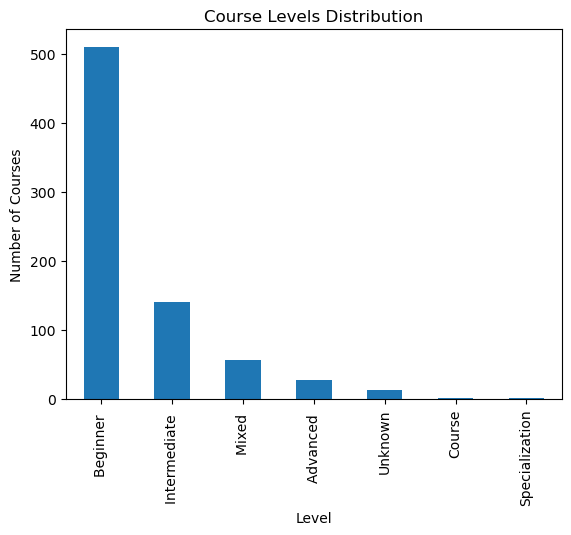

In [23]:
df['level'].value_counts().plot(
    kind='bar'
)

plt.title("Course Levels Distribution")

plt.xlabel("Level")
plt.ylabel("Number of Courses")

plt.show()

# Conclusion

A Personalized Learning Recommendation System was successfully developed using Content-Based Filtering.

The system leverages:

- TF-IDF Vectorization
- Cosine Similarity
- Skill-Based Recommendation

The model successfully recommends relevant courses based on user interests and course similarity, helping learners discover suitable educational content efficiently.